###  **Candidate number: 250036101 

# Assignment 3 (summative)

##  --------- Part 1 ---------

In this assignment you will use the Openweathermap Current Whether Data API to access weather information for cities in the UK. You need to sign up for an account with Openweathermap to get a Key. You will get 1,000 API calls per day for free. https://openweathermap.org/api

#### Q1. Get a list of all cities in the UK (excluding Crown Dependencies and Overseas Territories). (15 points)
Hint: To get the name of all cities in UK, consider scraping this website https://www.gov.uk/government/publications/list-of-cities/list-of-cities-html.

In [1]:
import requests
from bs4 import BeautifulSoup

url = "https://www.gov.uk/government/publications/list-of-cities/list-of-cities-html"
#print('done')

STOP_REGION = "Crown Dependencies"

response = requests.get(url)
response.raise_for_status()
soup = BeautifulSoup(response.text, "html.parser")

# only want main content, not the filters
main_content = soup.find("div", class_="gem-c-govspeak")

cities = []
current_region = None
capture_mode = True 

# cities we do not want to include
TERRITORY_CITIES = {"Douglas", "Hamilton", "City of Gibraltar", "Stanley", "Jamestown"}
INTRO_PHRASE = "List of cities (* indicates the city has also been awarded a Lord Mayoralty or Lord Provostship)"

# The regions are in <h2> tags, and the cities are in <ul> lists
for element in main_content.find_all(["h2", "ul"]):
    #stop processing before "Crown Dependencies"
    if element.name == "h2":
        current_region = element.get_text(strip=True)
        if current_region == STOP_REGION:
            capture_mode = False
            break 
    # Only process elements if in UK region
    if capture_mode and element.name == "ul" and current_region:
        for li in element.find_all("li"):
            city_entry = li.get_text(strip=True)
            
            # Filter out the territory cities
            if INTRO_PHRASE in city_entry:
                continue
            # Split out city name
            city_parts = city_entry.split("(")
            city = city_parts[0].strip()
            if city in TERRITORY_CITIES:
                continue
            if city and not city.lower().startswith("note"):
                cities.append({"region": current_region, "city": city})

print("List of cities in UK (excluding Crown Dependencies and Overseas Territories):")
print()
for entry in cities:
    print(entry['city'])
print()
print("* indicates the city has also been awarded a Lord Mayoralty or Lord Provostship")

#creating list for qestion 2 w/o *
uk_cities = [entry['city'] for entry in cities]
uk_cities = [entry['city'].replace('*', '') for entry in cities]

#print(cities)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
List of cities in UK (excluding Crown Dependencies and Overseas Territories):

Bath
Birmingham*
Bradford*
Brighton & Hove
Bristol*
Cambridge
Canterbury*
Carlisle
Chelmsford
Chester*
Chichester
Colchester
Coventry*
Derby
Doncaster
Durham
Ely
Exeter*
Gloucester
Hereford
Kingston-upon-Hull*
Lancaster
Leeds*
Leicester*
Lichfield
Lincoln
Liverpool*
London*
Manchester*
Milton Keynes
Newcastle-upon-Tyne*
Norwich*
Nottingham*
Oxford*
Peterborough
Plymouth*
Portsmouth*
Preston
Ripon
Salford
Salisbury
Sheffield*
Southampton*
Southend-on-Sea
St Albans
Stoke on Trent*
Sunderland
Truro
Wakefield
Wells
Westminster*
Winchester
Wolverhampton
Worcester
York*
Armagh*
Bangor
Belfast*
Lisburn
Londonderry
Newry
Aberdeen*
Dundee*
Dunfermline
Edinburgh*
Glasgow*
Inverness
Perth
Stirling
Bangor
Cardiff*
Newport
St Asaph
St Davids
Swansea*
Wrexham

* indicate

In [2]:
# changing Brighton and Hove to Bighton so data is found for next part
uk_cities[3] = 'Brighton'

print(uk_cities)

['Bath', 'Birmingham', 'Bradford', 'Brighton', 'Bristol', 'Cambridge', 'Canterbury', 'Carlisle', 'Chelmsford', 'Chester', 'Chichester', 'Colchester', 'Coventry', 'Derby', 'Doncaster', 'Durham', 'Ely', 'Exeter', 'Gloucester', 'Hereford', 'Kingston-upon-Hull', 'Lancaster', 'Leeds', 'Leicester', 'Lichfield', 'Lincoln', 'Liverpool', 'London', 'Manchester', 'Milton Keynes', 'Newcastle-upon-Tyne', 'Norwich', 'Nottingham', 'Oxford', 'Peterborough', 'Plymouth', 'Portsmouth', 'Preston', 'Ripon', 'Salford', 'Salisbury', 'Sheffield', 'Southampton', 'Southend-on-Sea', 'St Albans', 'Stoke on Trent', 'Sunderland', 'Truro', 'Wakefield', 'Wells', 'Westminster', 'Winchester', 'Wolverhampton', 'Worcester', 'York', 'Armagh', 'Bangor', 'Belfast', 'Lisburn', 'Londonderry', 'Newry', 'Aberdeen', 'Dundee', 'Dunfermline', 'Edinburgh', 'Glasgow', 'Inverness', 'Perth', 'Stirling', 'Bangor', 'Cardiff', 'Newport', 'St Asaph', 'St Davids', 'Swansea', 'Wrexham']


#### Q2. Use the Openweathermap Current Whether Data API to access the following information for each city: **main.temp, wind.speed, rain (1h) and Time of data calculation (dt)**. Use default units for these variables. Add the city name, temperature, wind, rain and dt information to a DataFrame as separate columns. If one of these attributes is missing, replace it with NONE. (25 points)
Hint: You may find it easier to create a dictionary with cities as keys and temperature, wind, rain and date as values first and then convert it into a DataFrame.

In [3]:
import pandas as pd
from datetime import datetime
import time

API_KEY = "ffba05c71309b00d1390eabd85ca76e4"
WEATHER_URL = "http://api.openweathermap.org/data/2.5/weather"
GEOCODING_URL = "http://api.openweathermap.org/geo/1.0/direct"


def get_coords(city_name, country_code="GB"):
    """Fetches latitude and longitude for a city using OpenWeatherMap's Geocoding API."""
    params = {
        'q': f"{city_name},{country_code}",
        'limit': 1,
        'appid': API_KEY,
    }
    try:
        response = requests.get(GEOCODING_URL, params=params)
        response.raise_for_status()
        data = response.json()
        
        if data and len(data) > 0:
            return data[0].get('lat'), data[0].get('lon')
        return None, None
    except requests.exceptions.RequestException as e:
        print(f"Geocoding error for {city_name}: {e}")
        return None, None

weather_data = {}

for city_name in uk_cities:
    
    # getting coordinates
    lat, lon = get_coords(city_name)
    if lat is None or lon is None:
        print(f"Could not find coordinates for {city_name}")
        # fill with NONE if geocoding fails
        weather_data[city_name] = {
            'Temperature (K)': 'NONE',
            'Wind Speed (m/s)': 'NONE',
            'Rain (1h) (mm)': 'NONE',
            'Time of Calculation': 'NONE'
        }
        time.sleep(1.5)
        continue

    # find Weather Data using lat/lon
    weather_params = {
        'lat': lat,
        'lon': lon,
        'appid': API_KEY,
    }

    try:
        response = requests.get(WEATHER_URL, params=weather_params)
        response.raise_for_status()
        data = response.json()
    
        time.sleep(1.5) 
        
        # main.temp: temperature (kelvin)
        temp = data.get('main', {}).get('temp', 'NONE')
        # wind.speed: wind speed (m/s)
        wind_speed = data.get('wind', {}).get('speed', 'NONE')
        # rain (1h): rain volume for the last 1 hour (mm)
        # should this be zero even though instructions say to replace it with NONE?
        rain_1h = data.get('rain', {}).get('1h', '0')
        # dt: time of data 
        dt_unix = data.get('dt', 'NONE') 
        dt_time = dt_unix

        weather_data[city_name] = {
            'Temperature (K)': temp,
            'Wind Speed (m/s)': wind_speed,
            'Rain (1h) (mm)': rain_1h,
            'Time of Calculation': dt_time
        }

    except requests.exceptions.RequestException as e:
        print(f"Weather API error for {city_name}: {e}. Skipping.")
        # If API call fails, fill with NONE
        weather_data[city_name] = {
            'Temperature (K)': 'NONE',
            'Wind Speed (m/s)': 'NONE',
            'Rain (1h) (mm)': 'NONE',
            'Time of Calculation': 'NONE'
        }


In [4]:
# creating df
df_weather = pd.DataFrame.from_dict(weather_data, orient='index')
df_weather = df_weather.reset_index().rename(columns={'index': 'City Name'})
# reordering columns: City Name, Temperature, Wind, Rain, dt
df_weather = df_weather[['City Name', 'Temperature (K)', 'Wind Speed (m/s)', 'Rain (1h) (mm)', 'Time of Calculation']]


print("Weather DF:")
print(df_weather)

Weather DF:
     City Name  Temperature (K)  Wind Speed (m/s) Rain (1h) (mm)  \
0         Bath           288.20              5.63              0   
1   Birmingham           286.75              3.09           0.32   
2     Bradford           286.30              2.57              0   
3     Brighton           288.74              2.57              0   
4      Bristol           288.26              4.63              0   
..         ...              ...               ...            ...   
70     Newport           288.47              7.16              0   
71    St Asaph           286.51              1.10           0.32   
72   St Davids           287.54              6.42              0   
73     Swansea           287.26              2.24           0.18   
74     Wrexham           285.84              3.60           1.15   

    Time of Calculation  
0            1762954388  
1            1762954051  
2            1762954084  
3            1762954392  
4            1762954257  
..             

In [5]:
#print(df_weather['Rain (1h) (mm)'].value_counts())  # Shows how many of each value
#print(f"\nNon-zero rain values: {(df_weather['Rain (1h) (mm)'] != 'NONE').sum()}")

#### Q3. The Time of data calculation (dt) is in Unix Timestamp format. Convert it to standard UTC (``dd/mm/yy @ HH:MM:SS``). Print out the updated DataFrame. (5 points)
Hint: You may use ``datetime.fromtimestamp`` to convert dt.

In [6]:
df_weather['Time of Calculation (UTC)'] = df_weather['Time of Calculation'].apply(
    lambda x: datetime.fromtimestamp(int(x)).strftime('%Y-%m-%d %H:%M:%S UTC')
    if x != 'NONE' else 'NONE'
)

print(df_weather)

     City Name  Temperature (K)  Wind Speed (m/s) Rain (1h) (mm)  \
0         Bath           288.20              5.63              0   
1   Birmingham           286.75              3.09           0.32   
2     Bradford           286.30              2.57              0   
3     Brighton           288.74              2.57              0   
4      Bristol           288.26              4.63              0   
..         ...              ...               ...            ...   
70     Newport           288.47              7.16              0   
71    St Asaph           286.51              1.10           0.32   
72   St Davids           287.54              6.42              0   
73     Swansea           287.26              2.24           0.18   
74     Wrexham           285.84              3.60           1.15   

    Time of Calculation Time of Calculation (UTC)  
0            1762954388   2025-11-12 13:33:08 UTC  
1            1762954051   2025-11-12 13:27:31 UTC  
2            1762954084   2

#### Q4. The default temperature units in Openweathermap are Kelvin. Convert it to Celsius. Print out the DataFrame. (5 points)
Hint: You may use the API to access the temperature in Celsius or use the convertion formula to convert the Kelvin values in your DataFrame. 

In [7]:
# kelvin = celcius + 273.15
# kelvin - 273.15 = celcius
#print(df_weather.dtypes)

df_weather['Temperature (K)'] = pd.to_numeric(df_weather['Temperature (K)'], errors='coerce') - 273.15
df_weather = df_weather.rename(columns={'Temperature (K)': 'Temperature (C)'})
print(df_weather)


     City Name  Temperature (C)  Wind Speed (m/s) Rain (1h) (mm)  \
0         Bath            15.05              5.63              0   
1   Birmingham            13.60              3.09           0.32   
2     Bradford            13.15              2.57              0   
3     Brighton            15.59              2.57              0   
4      Bristol            15.11              4.63              0   
..         ...              ...               ...            ...   
70     Newport            15.32              7.16              0   
71    St Asaph            13.36              1.10           0.32   
72   St Davids            14.39              6.42              0   
73     Swansea            14.11              2.24           0.18   
74     Wrexham            12.69              3.60           1.15   

    Time of Calculation Time of Calculation (UTC)  
0            1762954388   2025-11-12 13:33:08 UTC  
1            1762954051   2025-11-12 13:27:31 UTC  
2            1762954084   2

## --------- Part 2 ---------


In this assignment you will explore climate data for South East and Central South England from the MetOffice: <a href="https://www.metoffice.gov.uk/pub/data/weather/uk/climate/datasets/Tmean/date/England_SE_and_Central_S.txt">link</a>. 

**Please make sure all your plots have appropriate axes labels, titles, and legends (if applicable)!**

#### Q1. Load data and create a DataFrame indexed by year, where months, seasons and annual data are the attributes.

In [8]:
import pandas as pd
import requests 
from io import StringIO

url = 'https://www.metoffice.gov.uk/pub/data/weather/uk/climate/datasets/Tmean/date/England_SE_and_Central_S.txt'
response = requests.get(url, verify=False)

df_met = pd.read_csv(StringIO(response.text), skiprows=5, delim_whitespace=True)
df_met.set_index('year', inplace=True)

print(df_met.head())

      jan  feb  mar  apr   may   jun   jul   aug   sep   oct  nov  dec   win  \
year                                                                           
1884  6.1  5.4  6.4  6.9  11.6  14.0  16.3  17.4  14.9   9.2  5.4  4.7   ---   
1885  2.5  6.1  4.6  8.0   9.3  14.4  16.6  14.6  12.7   7.6  6.0  3.3  4.36   
1886  2.0  0.9  3.8  7.9  10.9  13.8  16.2  16.1  14.4  11.4  6.4  2.4  2.09   
1887  1.6  3.4  3.6  6.3   9.7  15.0  17.4  16.1  12.0   7.0  4.7  2.8  2.46   
1888  2.6  1.2  3.5  6.0  10.5  13.5  14.0  14.5  13.1   7.7  8.1  4.9  2.22   

       spr    sum    aut   ann  
year                            
1884  8.30  15.93   9.80  9.87  
1885  7.28  15.22   8.75  8.81  
1886  7.53  15.38  10.75  8.90  
1887  6.55  16.16   7.89  8.33  
1888  6.66  14.02   9.61  8.32  


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.metoffice.gov.uk'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/var/folders/rf/_j3921_x3sz9jdtwzd1sj4lh0000gn/T/ipykernel_88080/2840914334.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_met = pd.read_csv(StringIO(response.text), skiprows=5, delim_whitespace=True)


#### Q2. Plot the line plots for monthly averages.

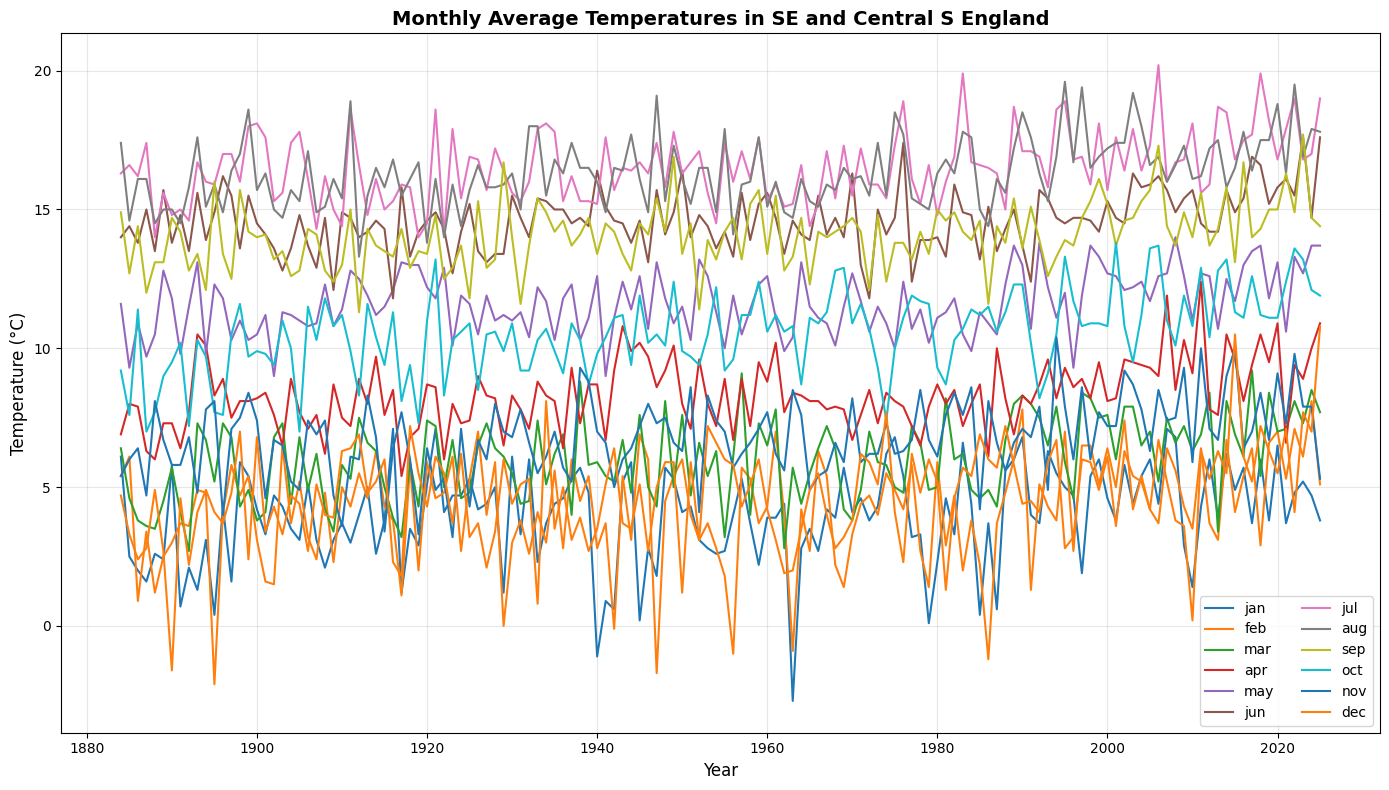

In [9]:
import matplotlib.pyplot as plt

month_cols = df_met.columns[:12]
monthly_data = df_met[month_cols]

# monthly averages over time
plt.figure(figsize=(14, 8))

for month in month_cols:
    plt.plot(monthly_data.index, monthly_data[month], label=month, linewidth=1.5)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Monthly Average Temperatures in SE and Central S England', fontsize=14, fontweight='bold')
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plot is hard to read
# make the plot easier to read following slides 
# make new plot with each month highlighted and other months grayed out in following code block

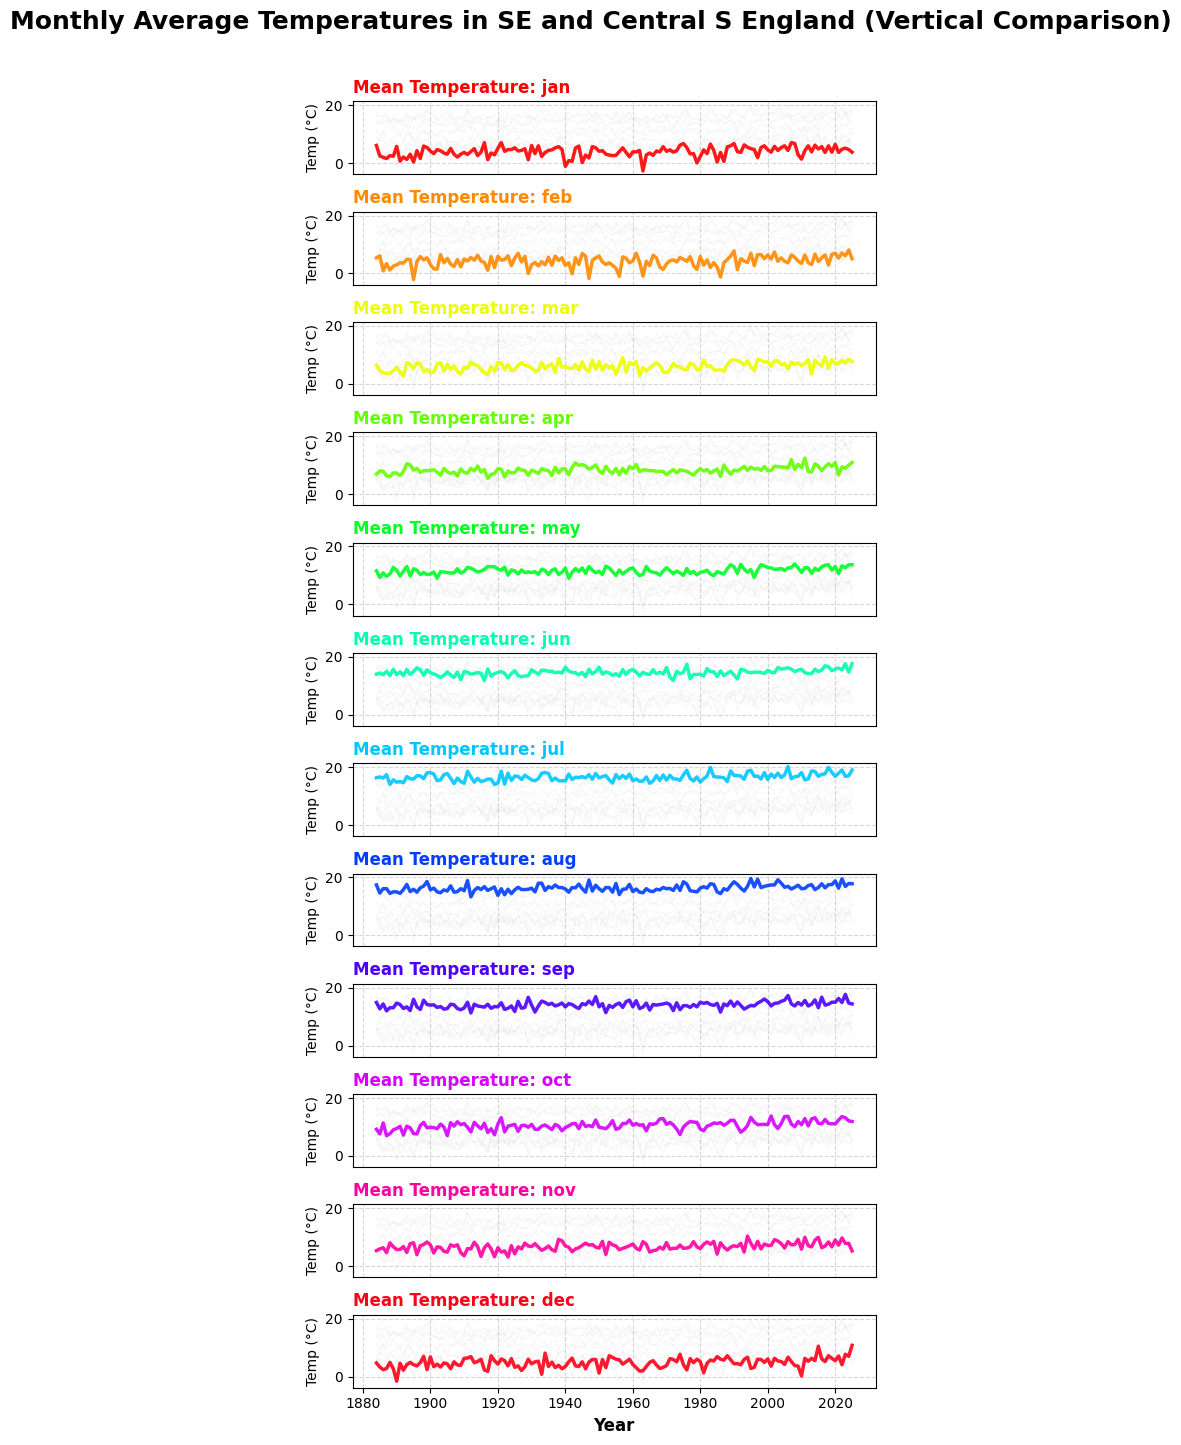

In [7]:
fig, axes = plt.subplots(12, 1, figsize=(6, 15), sharex=True)
axes = axes.flatten() 

# color palette for the 12 months
colors = plt.cm.get_cmap('hsv', 12)

# loop through each month to create a dedicated subplot
for i, target_month in enumerate(month_cols):
    ax = axes[i]
    # plot all other months as grey background lines
    other_months = [m for m in month_cols if m != target_month]
    for other_month in other_months:
        ax.plot(monthly_data.index, monthly_data[other_month], 
                color='lightgray', 
                alpha=0.15,  
                linewidth=1,
                zorder=1) 
        
    # plot the target month prominently
    ax.plot(monthly_data.index, monthly_data[target_month], 
            color=colors(i), 
            alpha=0.9, 
            linewidth=2.5, 
            label=target_month,
            zorder=2) 
    
    # title for the current subplot
    ax.set_title(f'Mean Temperature: {target_month}', 
                 fontsize=12, 
                 fontweight='bold', 
                 color=colors(i),
                 loc='left') # Align title left
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    # Y-axis label to every plot bc the range varies widely
    ax.set_ylabel('Temp (°C)', fontsize=10)
    # remove X-axis ticks/labels from all but the bottom plot
    if i < 11:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    else:
        # X-axis label only to the last plot (December)
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')

# main title and adjust layout
fig.suptitle('Monthly Average Temperatures in SE and Central S England (Vertical Comparison)', 
             fontsize=18, 
             fontweight='bold', 
             y=0.99) 
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

#### Q3. Plot the monthly average box plots (with months on the x-axis and temperature on the y-axis).

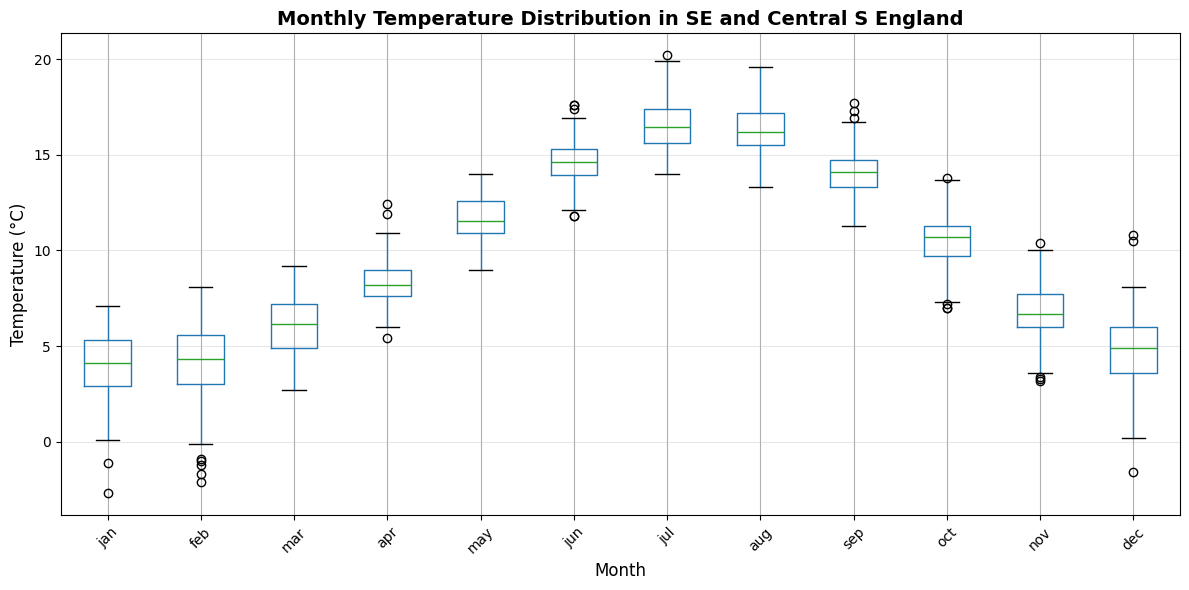

In [22]:
plt.figure(figsize=(12, 6))
monthly_data.boxplot(column=list(month_cols))

plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Monthly Temperature in SE and Central S England', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### Q4. Plot the histograms of annual temperatures for all years until and including 1970 and all years after 1970.

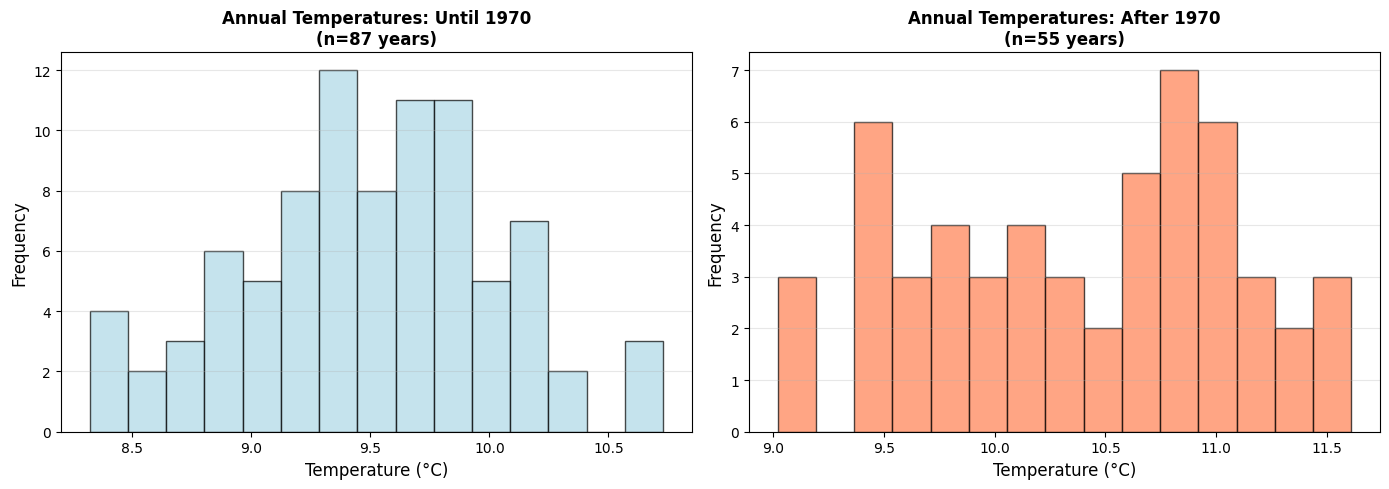

Until 1970 - Mean: 9.50°C, Std: 0.54°C
After 1970 - Mean: 10.37°C, Std: 0.71°C


In [10]:
annual_temps = df_met['ann']

# data split into two periods
temps_until_1970 = annual_temps[annual_temps.index <= 1970]
temps_after_1970 = annual_temps[annual_temps.index > 1970]

# two histograms 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# years until and including 1970
axes[0].hist(temps_until_1970, bins=15, color='lightblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Annual Temperatures: Until 1970\n(n={len(temps_until_1970)} years)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# years after 1970
axes[1].hist(temps_after_1970, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Temperature (°C)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Annual Temperatures: After 1970\n(n={len(temps_after_1970)} years)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# summary stats to help answer the follwing question 
print(f"Until 1970 - Mean: {temps_until_1970.mean():.2f}°C, Std: {temps_until_1970.std():.2f}°C")
print(f"After 1970 - Mean: {temps_after_1970.mean():.2f}°C, Std: {temps_after_1970.std():.2f}°C")
# creating an overlayed histogram in the following plot to 
# better visualize the data following the lecture slides

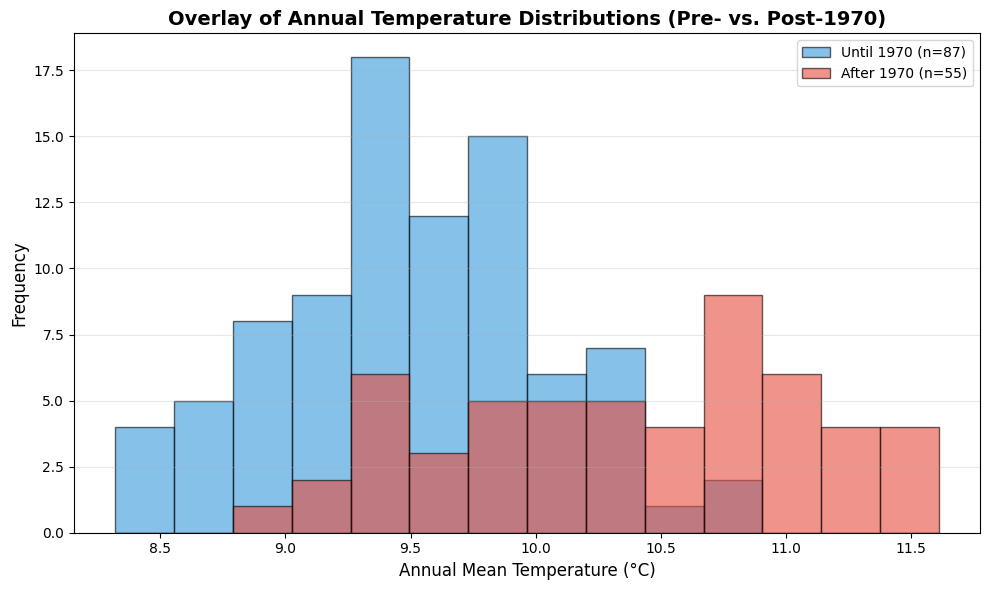

In [12]:
import numpy as np

min_temp = annual_temps.min()
max_temp = annual_temps.max()
bins = np.linspace(min_temp, max_temp, 15)

#  overlay plot
plt.figure(figsize=(10, 6))
ax = plt.gca() 

# years until 1970 
ax.hist(temps_until_1970, 
        bins=bins, 
        color='#3498db', # Blue
        edgecolor='black', 
        alpha=0.6, 
        label=f'Until 1970 (n={len(temps_until_1970)})')

# years after 1970 
ax.hist(temps_after_1970, 
        bins=bins, 
        color='#e74c3c', # Red/Coral
        edgecolor='black', 
        alpha=0.6, 
        label=f'After 1970 (n={len(temps_after_1970)})')

# labels and title
ax.set_xlabel('Annual Mean Temperature (°C)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Overlay of Annual Temperature Distributions (Pre- vs. Post-1970)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Q5. What hypothesis could be raised based on the figure in Q4?

The mean in the histogram from after 1970 is higher than the mean in the until 1970 histograms, which implies that the temperatures in England SE and central S are increasing. 

We could conduct a hypothesis test to confirm folling:
H_0 (Null): There is no significant difference in mean annual temperature between the period until 1970 and after 1970.
H_1 (Alternative): The mean annual temperature after 1970 is higher than the period until 1970.

We can also see from the histograms that the period after 1970 has a higher standard deviation and variatability than the period until 1970. 

We can conduct the following hypothesis test to confirm:
H_0: The variability (standard deviation) of annual temperatures is the same before and after 1970.
H_1: The variability of annual temperatures has changed after 1970.

#### Q6. Calculate a 10-year rolling mean for the annual temperature and plot it in the same plot as the original annual data.
Hint: You may use pandas ``rolling`` function.

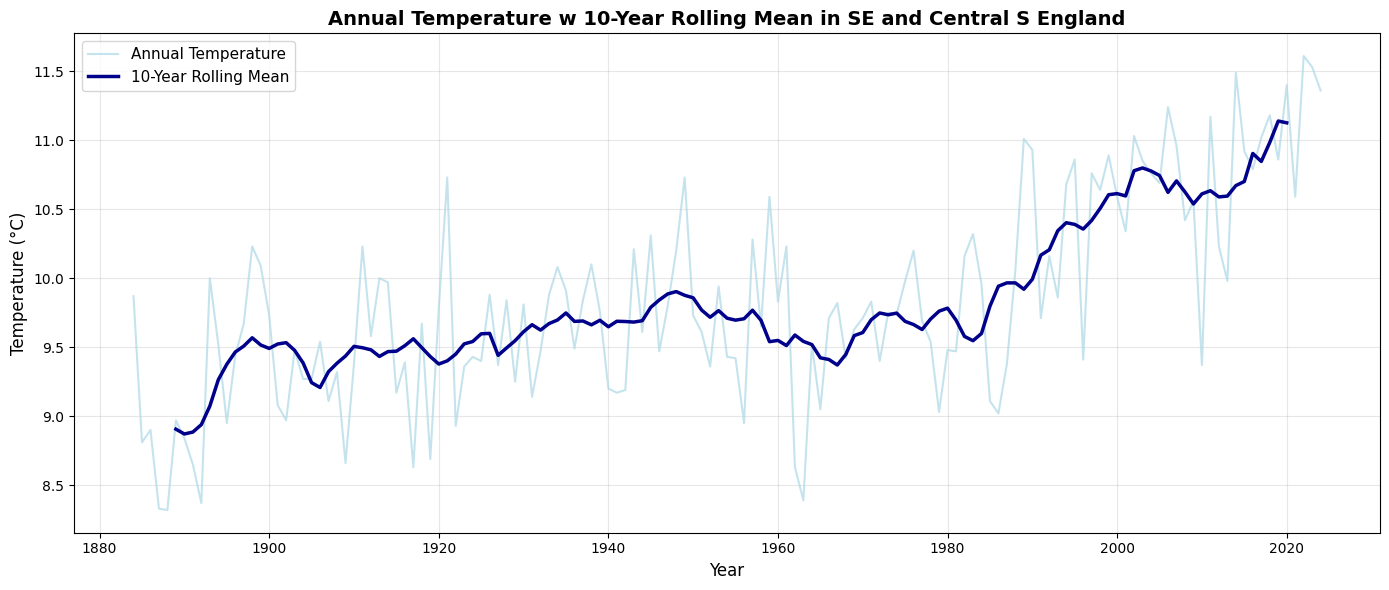

In [49]:
rolling_mean_10 = annual_temps.rolling(window=10, center=True).mean()

# original and rolling mean
plt.figure(figsize=(14, 6))

plt.plot(annual_temps.index, annual_temps, label='Annual Temperature', 
         color='lightblue', linewidth=1.5, alpha=0.7)
plt.plot(rolling_mean_10.index, rolling_mean_10, label='10-Year Rolling Mean', 
         color='darkblue', linewidth=2.5)

# making plot pretty
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Annual Temperature w 10-Year Rolling Mean in SE and Central S England', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Q7. Plot the <a href="https://en.wikipedia.org/wiki/Warming_stripes">warming stripes</a> using annual temperature. Use ``sns.heatmap`` with ``cmap="coolwarm"`` as colour map. Make the stripes vertical (for example, by transposing the data).

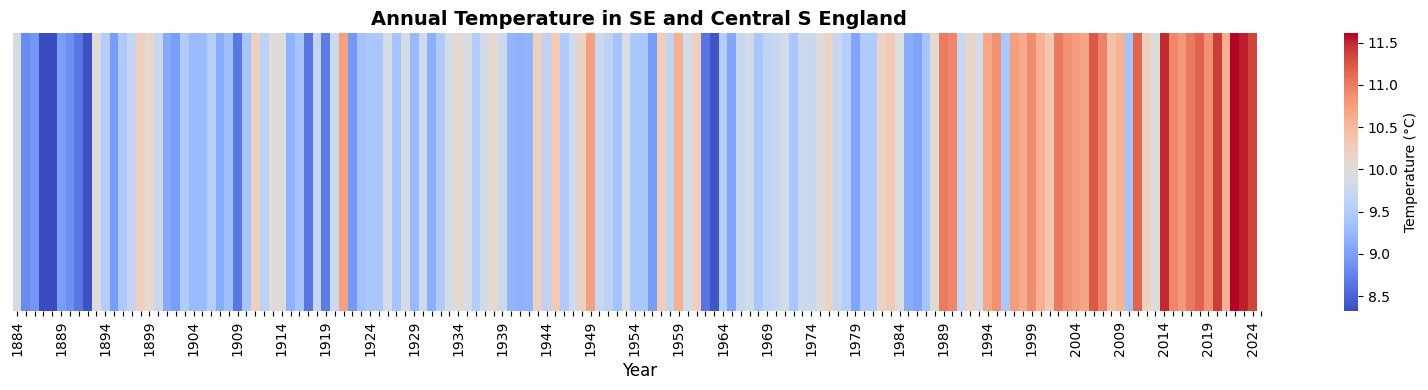

In [48]:
import seaborn as sns
temps_reshaped = annual_temps.values.reshape(1, -1)

plt.figure(figsize=(16, 4))

sns.heatmap(temps_reshaped, 
            cmap="coolwarm",
            cbar=True,
            xticklabels=annual_temps.index,
            yticklabels=False,
            cbar_kws={'label': 'Temperature (°C)'})

# only showing every 5th year on axis
ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 5 != 0:
        label.set_visible(False)


plt.xlabel('Year', fontsize=12)
plt.title('Annual Temperature in SE and Central S England', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Q8. Calculate the average annual temperature with respect to the mean of 1961-1990 and plot as warming stripes (as in Q7). 
You may want to create a separate attribute in your DataFrame called Anomaly that contains the difference between annual temperatures for each year and the mean annual temperature for the reference years, 1961-1990.

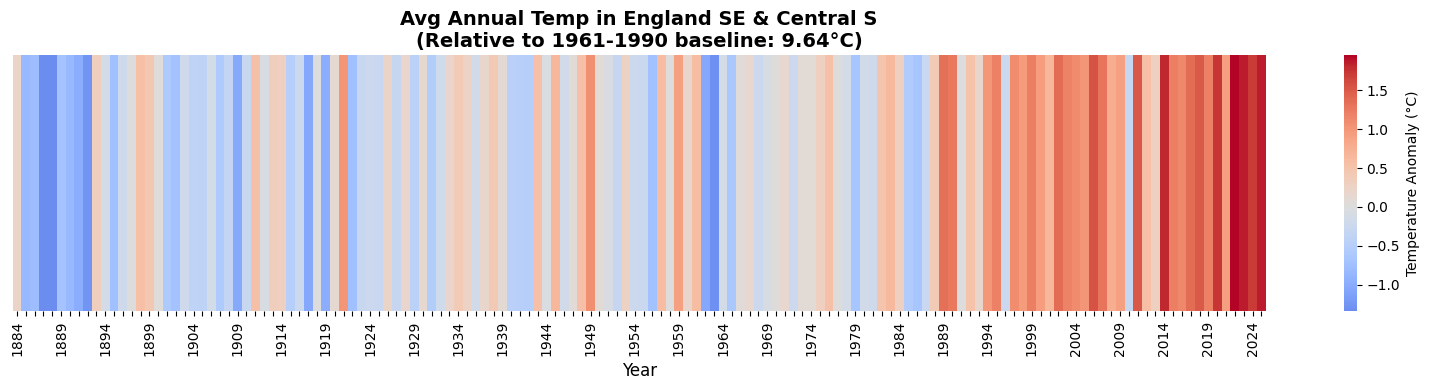

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_met['ann_mean'] = monthly_data.mean(axis=1)

# baseline (1961-1990 mean)
baseline_years = df_met.loc[1961:1990]
baseline_mean = baseline_years['ann_mean'].mean()

# calc temperature anomaly
df_met['anomaly'] = df_met['ann_mean'] - baseline_mean

# make anomaly data into a single row df
anomaly_2d = df_met['anomaly'].values.reshape(1, -1)

plt.figure(figsize=(16, 4))
sns.heatmap(anomaly_2d, 
            cmap="coolwarm",
            cbar=True,
            xticklabels=df_met.index,  
            yticklabels=False,
            cbar_kws={'label': 'Temperature Anomaly (°C)'},
            center=0)  

plt.title(f'Avg Annual Temp in England SE & Central S\n(Relative to 1961-1990 baseline: {baseline_mean:.2f}°C)', 
          fontsize=14, fontweight='bold')

# only showing every 5th year on axis
ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 5 != 0:
        label.set_visible(False)
plt.xlabel('Year', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Q9. Plot the warming stripes for the 10-year rolling mean from Q6 with respect to the mean of 1961-1990.
As in Q8, you may want to add an attribute to your DataFrame for 10yr_Rolling_Mean_Anomaly that includes the difference between the rolling mean and the mean for the reference years.

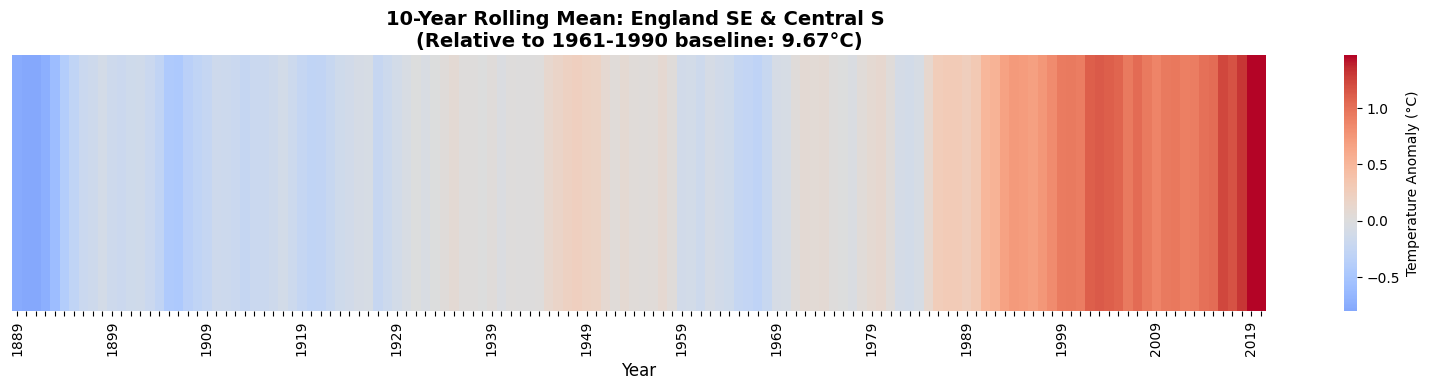

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# calc the baseline (1961-1990 mean) from the rolling mean
baseline_rolling = rolling_mean_10.loc[1961:1990].mean()
# calc the 10-year rolling mean anomaly
df_met['10yr_Rolling_Mean_Anomaly'] = rolling_mean_10 - baseline_rolling

# remove NaN values
rolling_anomaly_clean = df_met['10yr_Rolling_Mean_Anomaly'].dropna()
# reshaping to 2D
anomaly_2d = rolling_anomaly_clean.values.reshape(1, -1)


year_labels = [year if i % 10 == 0 else '' for i, year in enumerate(rolling_anomaly_clean.index)]

plt.figure(figsize=(16, 4))
sns.heatmap(anomaly_2d, 
            cmap="coolwarm",
            cbar=True,
            xticklabels=year_labels,  
            yticklabels=False,
            cbar_kws={'label': 'Temperature Anomaly (°C)'},
            center=0)  

plt.title(f'10-Year Rolling Mean: England SE & Central S \n(Relative to 1961-1990 baseline: {baseline_rolling:.2f}°C)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

AI Ackowledgement:

I acknowledge the use of ChatGPT (https://chatgpt.com/) for debugging my code as well as asking for python syntax help. I also used ChatGPT to clarify some of the questions (ex what is a rolling mean?) I have uploaded the pdf file of my prompts.

In [ ]:
# 